In [1]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_auc_score, classification_report
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_score
)
import joblib

SEED = 42
np.random.seed(SEED)

print("✅ All libraries imported")

✅ All libraries imported


In [2]:
# Verify all files from notebook 02 exist before doing anything

REQUIRED = [
    "../data/processed/X_train_balanced.csv",
    "../data/processed/y_train_balanced.csv",
    "../data/processed/X_test.csv",
    "../data/processed/y_test.csv",
    "../data/processed/feature_names.csv",
]

missing = [f for f in REQUIRED if not os.path.exists(f)]

if missing:
    print("❌ Missing files — run 02_preprocessing.ipynb first and re-run Cell 14:")
    for f in missing:
        print(f"   • {f}")
    raise FileNotFoundError("Run 02_preprocessing.ipynb first.")
else:
    print("✅ All required files found. Safe to proceed.")

✅ All required files found. Safe to proceed.


In [3]:
# Load every variable from saved CSVs
# This is why notebook 03 works independently — no memory dependency on notebook 02

X_train = pd.read_csv("../data/processed/X_train_balanced.csv").values
y_train = pd.read_csv("../data/processed/y_train_balanced.csv").values.ravel()

X_test  = pd.read_csv("../data/processed/X_test.csv").values
y_test  = pd.read_csv("../data/processed/y_test.csv").values.ravel()

feature_names = (
    pd.read_csv("../data/processed/feature_names.csv")["feature"].tolist()
)

# ── Sanity checks ──────────────────────────────────────────────────────────────
assert X_train.shape[1] == len(feature_names), (
    f"Mismatch: X_train has {X_train.shape[1]} columns "
    f"but feature_names has {len(feature_names)} entries. "
    f"Re-run 02_preprocessing.ipynb."
)

assert X_test.shape[1] == X_train.shape[1], (
    "X_train and X_test have different number of columns."
)

print("Data loaded from disk:")
print(f"  X_train : {X_train.shape}  ← SMOTE balanced (should be ~50/50)")
print(f"  y_train : {y_train.shape}  | churn rate: {y_train.mean()*100:.1f}%")
print(f"  X_test  : {X_test.shape}   ← original imbalance preserved")
print(f"  y_test  : {y_test.shape}   | churn rate: {y_test.mean()*100:.1f}%")
print(f"  features: {len(feature_names)}")

print("\nClass distribution in training set (after SMOTE):")
vals, cnts = np.unique(y_train, return_counts=True)
for v, c in zip(vals, cnts):
    label = "Churn" if v == 1 else "No Churn"
    print(f"  {v} ({label:9s}): {c:,}  ({c/len(y_train)*100:.1f}%)")

Data loaded from disk:
  X_train : (8260, 40)  ← SMOTE balanced (should be ~50/50)
  y_train : (8260,)  | churn rate: 50.0%
  X_test  : (1407, 40)   ← original imbalance preserved
  y_test  : (1407,)   | churn rate: 26.6%
  features: 40

Class distribution in training set (after SMOTE):
  0 (No Churn ): 4,130  (50.0%)
  1 (Churn    ): 4,130  (50.0%)


In [4]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Fit model on training data, evaluate on test data.
    Returns a dict of metrics.
    Cross-validation is on training data only — no test leakage.
    """
    # Train
    model.fit(X_tr, y_tr)

    # Predict
    y_pred = model.predict(X_te)
    y_prob = (
        model.predict_proba(X_te)[:, 1]
        if hasattr(model, "predict_proba") else None
    )

    # 5-fold cross-validation on training set only
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_f1 = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="f1")

    metrics = {
        "Model"       : name,
        "Accuracy"    : round(accuracy_score(y_te, y_pred)  * 100, 2),
        "Precision"   : round(precision_score(y_te, y_pred, zero_division=0) * 100, 2),
        "Recall"      : round(recall_score(y_te, y_pred,    zero_division=0) * 100, 2),
        "F1 Score"    : round(f1_score(y_te, y_pred,        zero_division=0) * 100, 2),
        "AUC-ROC"     : round(roc_auc_score(y_te, y_prob), 4) if y_prob is not None else "N/A",
        "CV F1 Mean"  : round(cv_f1.mean() * 100, 2),
        "CV F1 Std"   : round(cv_f1.std()  * 100, 2),
    }
    return metrics, model

print("✅ evaluate_model() ready")

✅ evaluate_model() ready


In [5]:
baseline_configs = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=SEED
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=SEED
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=SEED, n_jobs=-1
    ),
}

all_results    = []
trained_models = {}

for name, model in baseline_configs.items():
    print(f"Training {name}...", end="  ")
    metrics, fitted_model = evaluate_model(
        name, model, X_train, y_train, X_test, y_test
    )
    all_results.append(metrics)
    trained_models[name] = fitted_model
    print(
        f"Accuracy: {metrics['Accuracy']}%  |  "
        f"F1: {metrics['F1 Score']}%  |  "
        f"AUC: {metrics['AUC-ROC']}"
    )

results_df = pd.DataFrame(all_results).set_index("Model")
print("\n── Baseline Results ─────────────────────────────────────────")
print(results_df.to_string())

Training Logistic Regression...  Accuracy: 73.28%  |  F1: 60.91%  |  AUC: 0.8339
Training Decision Tree...  Accuracy: 73.28%  |  F1: 54.59%  |  AUC: 0.6918
Training Random Forest...  Accuracy: 77.47%  |  F1: 58.45%  |  AUC: 0.8131

── Baseline Results ─────────────────────────────────────────
                     Accuracy  Precision  Recall  F1 Score  AUC-ROC  CV F1 Mean  CV F1 Std
Model                                                                                     
Logistic Regression     73.28      49.83   78.34     60.91   0.8339       79.35       0.24
Decision Tree           73.28      49.78   60.43     54.59   0.6918       78.91       0.81
Random Forest           77.47      57.33   59.63     58.45   0.8131       85.48       0.25


In [6]:
print("── Full Classification Reports ──────────────────────────────\n")

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(
        y_test, y_pred,
        target_names=["No Churn (0)", "Churn (1)"]
    ))

── Full Classification Reports ──────────────────────────────

  Logistic Regression
              precision    recall  f1-score   support

No Churn (0)       0.90      0.71      0.80      1033
   Churn (1)       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407

  Decision Tree
              precision    recall  f1-score   support

No Churn (0)       0.84      0.78      0.81      1033
   Churn (1)       0.50      0.60      0.55       374

    accuracy                           0.73      1407
   macro avg       0.67      0.69      0.68      1407
weighted avg       0.75      0.73      0.74      1407

  Random Forest
              precision    recall  f1-score   support

No Churn (0)       0.85      0.84      0.85      1033
   Churn (1)       0.57      0.60      0.58       374

    accuracy                           0.77      1407
   macro av

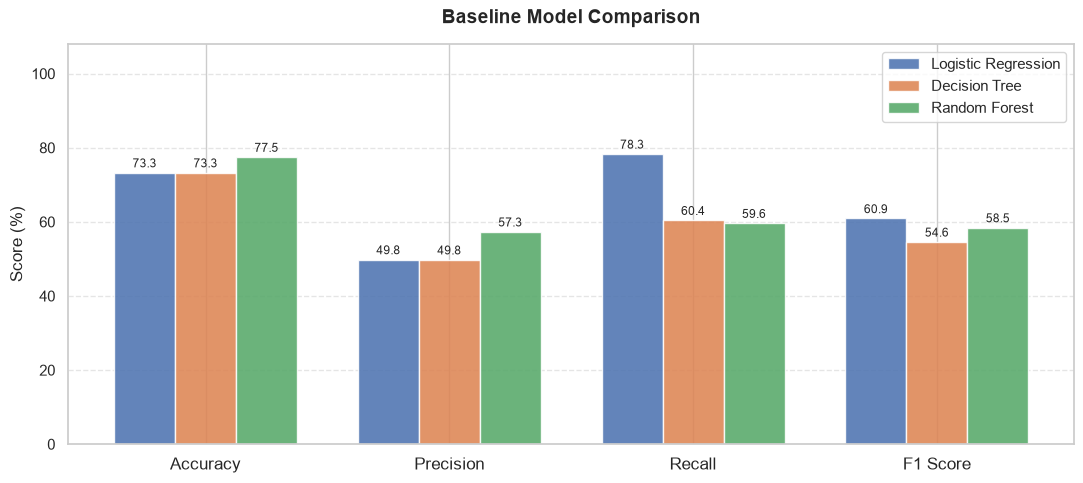

✅ Saved: images/baseline_comparison.png


In [7]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score"]
plot_df = results_df[metrics_to_plot].astype(float)

fig, ax = plt.subplots(figsize=(11, 5))

x      = np.arange(len(metrics_to_plot))
width  = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]
models_list = plot_df.index.tolist()

for i, (model_name, row) in enumerate(plot_df.iterrows()):
    offset = (i - 1) * width
    bars = ax.bar(
        x + offset, row.values, width,
        label=model_name, color=colors[i], alpha=0.87, edgecolor="white"
    )
    ax.bar_label(bars, fmt="%.1f", fontsize=8.5, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=12)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_ylim(0, 108)
ax.set_title("Baseline Model Comparison", fontsize=14,
             fontweight="bold", pad=15)
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

os.makedirs("../images", exist_ok=True)
plt.tight_layout()
plt.savefig("../images/baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: images/baseline_comparison.png")

In [8]:
# Use F1 Score to select best model
# Why F1 not Accuracy? Test set is still ~27% churners.
# A model predicting "No Churn" for everyone gets ~73% accuracy
# but has 0% F1 on churners — completely useless for retention.

best_name = results_df["F1 Score"].astype(float).idxmax()
print(f"Best baseline model : {best_name}")
print(f"F1 Score            : {results_df.loc[best_name, 'F1 Score']}%")
print(f"AUC-ROC             : {results_df.loc[best_name, 'AUC-ROC']}")
print(f"\n→ Proceeding to hyperparameter tuning for Random Forest")

Best baseline model : Logistic Regression
F1 Score            : 60.91%
AUC-ROC             : 0.8339

→ Proceeding to hyperparameter tuning for Random Forest


In [12]:
# GridSearchCV tests every combination in param_grid
# cv=StratifiedKFold → each fold preserves class ratio
# scoring='f1'       → optimise for F1 (not accuracy)
# refit=True         → automatically refit best model on full X_train after search
#
# ⚠️  X_test is NEVER used here — leakage prevention

param_grid = {
    "n_estimators"     : [100, 200, 300],
    "max_depth"        : [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4],
    "class_weight"     : [None, "balanced"],
}

total_combos = 1
for v in param_grid.values():
    total_combos *= len(v)

print(f"Total parameter combinations : {total_combos}")
print(f"With 5-fold CV               : {total_combos * 5} model fits")
print(f"Estimated time               : 3–10 minutes depending on CPU\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_grid = param_grid,
    cv         = cv,
    scoring    = "f1",
    n_jobs     = -1,
    verbose    = 1,
    refit      = True,
)

grid_search.fit(X_train, y_train)

print("\n── GridSearchCV Results ─────────────────────────────────────")
print(f"Best CV F1 Score  : {grid_search.best_score_ * 100:.2f}%")
print(f"Best Parameters   :")
for param, value in grid_search.best_params_.items():
    print(f"  {param:25s}: {value}")

Total parameter combinations : 162
With 5-fold CV               : 810 model fits
Estimated time               : 3–10 minutes depending on CPU

Fitting 5 folds for each of 162 candidates, totalling 810 fits

── GridSearchCV Results ─────────────────────────────────────
Best CV F1 Score  : 85.97%
Best Parameters   :
  class_weight             : balanced
  max_depth                : 20
  min_samples_leaf         : 1
  min_samples_split        : 2
  n_estimators             : 200


In [13]:
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)
y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

tuned_results = {
    "Accuracy"  : accuracy_score(y_test, y_pred_tuned)  * 100,
    "Precision" : precision_score(y_test, y_pred_tuned) * 100,
    "Recall"    : recall_score(y_test, y_pred_tuned)    * 100,
    "F1 Score"  : f1_score(y_test, y_pred_tuned)        * 100,
    "AUC-ROC"   : roc_auc_score(y_test, y_prob_tuned),
}

# Compare baseline vs tuned
baseline_f1 = float(results_df.loc["Random Forest", "F1 Score"])
tuned_f1    = tuned_results["F1 Score"]

print("── Tuned Random Forest — Test Set ──────────────────────────")
for k, v in tuned_results.items():
    unit = "%" if k != "AUC-ROC" else ""
    print(f"  {k:12s}: {v:.4f}{unit}")

print(f"\nF1 improvement over baseline RF : {tuned_f1 - baseline_f1:+.2f}%")

print("\n── Full Classification Report ───────────────────────────────")
print(classification_report(
    y_test, y_pred_tuned,
    target_names=["No Churn", "Churn"]
))

── Tuned Random Forest — Test Set ──────────────────────────
  Accuracy    : 77.6830%
  Precision   : 57.5758%
  Recall      : 60.9626%
  F1 Score    : 59.2208%
  AUC-ROC     : 0.8150

F1 improvement over baseline RF : +0.77%

── Full Classification Report ───────────────────────────────
              precision    recall  f1-score   support

    No Churn       0.86      0.84      0.85      1033
       Churn       0.58      0.61      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



Top 15 Features:
                       Feature  Importance
                        tenure    0.118571
                  TotalCharges    0.111479
                MonthlyCharges    0.103327
       Contract_Month-to-month    0.100928
                TechSupport_No    0.050049
             OnlineSecurity_No    0.043624
PaymentMethod_Electronic check    0.035925
             Contract_Two year    0.034462
              PaperlessBilling    0.032079
   InternetService_Fiber optic    0.029418
                        gender    0.028611
                       Partner    0.027490
                    Dependents    0.022589
             Contract_One year    0.020237
               OnlineBackup_No    0.017591


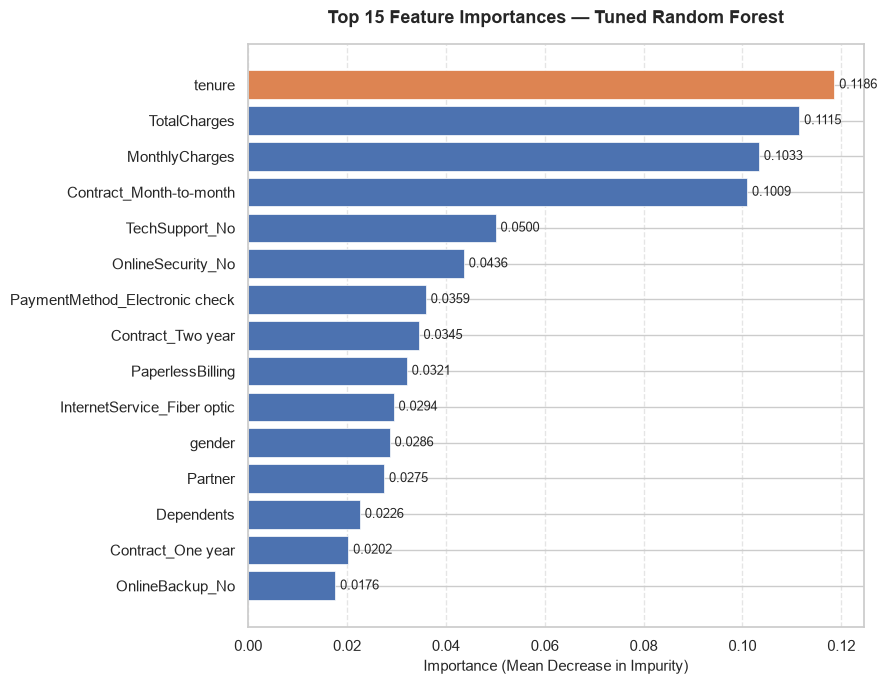

✅ Saved: images/feature_importance.png


In [14]:
importance_df = pd.DataFrame({
    "Feature"   : feature_names,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top 15 Features:")
print(importance_df.head(15).to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
TOP_N     = 15
plot_data = importance_df.head(TOP_N).iloc[::-1]   # reverse for horizontal bar

bar_colors = [
    "#DD8452" if i == len(plot_data) - 1 else "#4C72B0"
    for i in range(len(plot_data))
]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(
    plot_data["Feature"],
    plot_data["Importance"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.4f}",
        va="center", ha="left", fontsize=9
    )

ax.set_xlabel("Importance (Mean Decrease in Impurity)", fontsize=11)
ax.set_title(
    f"Top {TOP_N} Feature Importances — Tuned Random Forest",
    fontsize=13, fontweight="bold", pad=15
)
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../images/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: images/feature_importance.png")

In [15]:
import json
from datetime import datetime

os.makedirs("../models", exist_ok=True)

# Save model
MODEL_PATH = "../models/best_model.pkl"
joblib.dump(best_rf, MODEL_PATH)

# Save metadata alongside the model
metadata = {
    "model_type"    : "RandomForestClassifier",
    "trained_on"    : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "n_features"    : len(feature_names),
    "feature_names" : feature_names,
    "best_params"   : grid_search.best_params_,
    "test_metrics"  : {k: round(v, 4) for k, v in tuned_results.items()},
}

META_PATH = "../models/best_model_metadata.json"
with open(META_PATH, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"✅ Model saved    → {MODEL_PATH}")
print(f"   File size      : {os.path.getsize(MODEL_PATH)/1024:.1f} KB")
print(f"✅ Metadata saved → {META_PATH}")

print("\n── Final Summary ────────────────────────────────────────────")
print(f"  Model     : {metadata['model_type']}")
print(f"  Features  : {metadata['n_features']}")
print(f"  Accuracy  : {metadata['test_metrics']['Accuracy']}%")
print(f"  F1 Score  : {metadata['test_metrics']['F1 Score']}%")
print(f"  AUC-ROC   : {metadata['test_metrics']['AUC-ROC']}")
print("\n✅ 03_model_building.ipynb complete.")
print("   Next step: Run 04_model_evaluation.ipynb")

✅ Model saved    → ../models/best_model.pkl
   File size      : 43986.6 KB
✅ Metadata saved → ../models/best_model_metadata.json

── Final Summary ────────────────────────────────────────────
  Model     : RandomForestClassifier
  Features  : 40
  Accuracy  : 77.683%
  F1 Score  : 59.2208%
  AUC-ROC   : 0.815

✅ 03_model_building.ipynb complete.
   Next step: Run 04_model_evaluation.ipynb
